# Credit Fraud Detection — Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import sys
from pathlib import Path

# Find project root dynamically
current = Path.cwd()

while current.name != "credit_fraud_ml":
    current = current.parent

# Change working directory to project root so relative paths resolve correctly
os.chdir(current)

# Add project root to path
sys.path.append(str(current))

print("Project root:", current)
print("Working directory:", Path.cwd())
print("\nPython path updated successfully!")

from src.data.data_loader import DataLoader

loader = DataLoader()
data = loader.load_all('train')

transactions = data['transactions']
customers = data['customers']
terminals = data['terminals']

print(transactions.shape)
print(customers.shape)
print(terminals.shape)

Project root: /Users/kgothatso/Downloads/credit_fraud_ml
Working directory: /Users/kgothatso/Downloads/credit_fraud_ml

Python path updated successfully!
✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
(291231, 6)
(1000, 8)
(2000, 3)


In [2]:
transactions.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD
0,59383,2021-08-01 00:04:37,323,217,4.60,0
1,59384,2021-08-01 00:12:10,6,429,8.61,0
2,59385,2021-08-01 00:12:34,714,1011,64.00,0
3,59386,2021-08-01 00:15:40,266,1969,12.72,0
4,59387,2021-08-01 00:16:01,890,1482,98.88,0


In [3]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291231 entries, 0 to 291230
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   TRANSACTION_ID  291231 non-null  int64         
 1   TX_DATETIME     291231 non-null  datetime64[ns]
 2   CUSTOMER_ID     291231 non-null  int64         
 3   TERMINAL_ID     291231 non-null  int64         
 4   TX_AMOUNT       291231 non-null  float64       
 5   TX_FRAUD        291231 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 13.3 MB


In [4]:
transactions.describe()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD
count,291231.000000,291231,291231.000000,291231.000000,291231.000000,291231.000000
mean,204998.000000,2021-10-16 02:06:44.044813056,496.256202,993.718526,53.182274,0.022601
min,59383.000000,2021-08-01 00:04:37,0.000000,0.000000,0.000000,0.000000
25%,132190.500000,2021-09-08 05:17:43.500000,249.000000,496.000000,21.130000,0.000000
50%,204998.000000,2021-10-16 05:55:26,498.000000,1000.000000,44.770000,0.000000
75%,277805.500000,2021-11-23 06:15:18.500000,741.000000,1483.000000,76.850000,0.000000
max,350613.000000,2021-12-30 23:58:21,999.000000,1999.000000,291.150000,1.000000
std,84071.292461,NaN,285.274966,575.267551,39.573329,0.148627


In [5]:
missing = transactions.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Series([], dtype: int64)

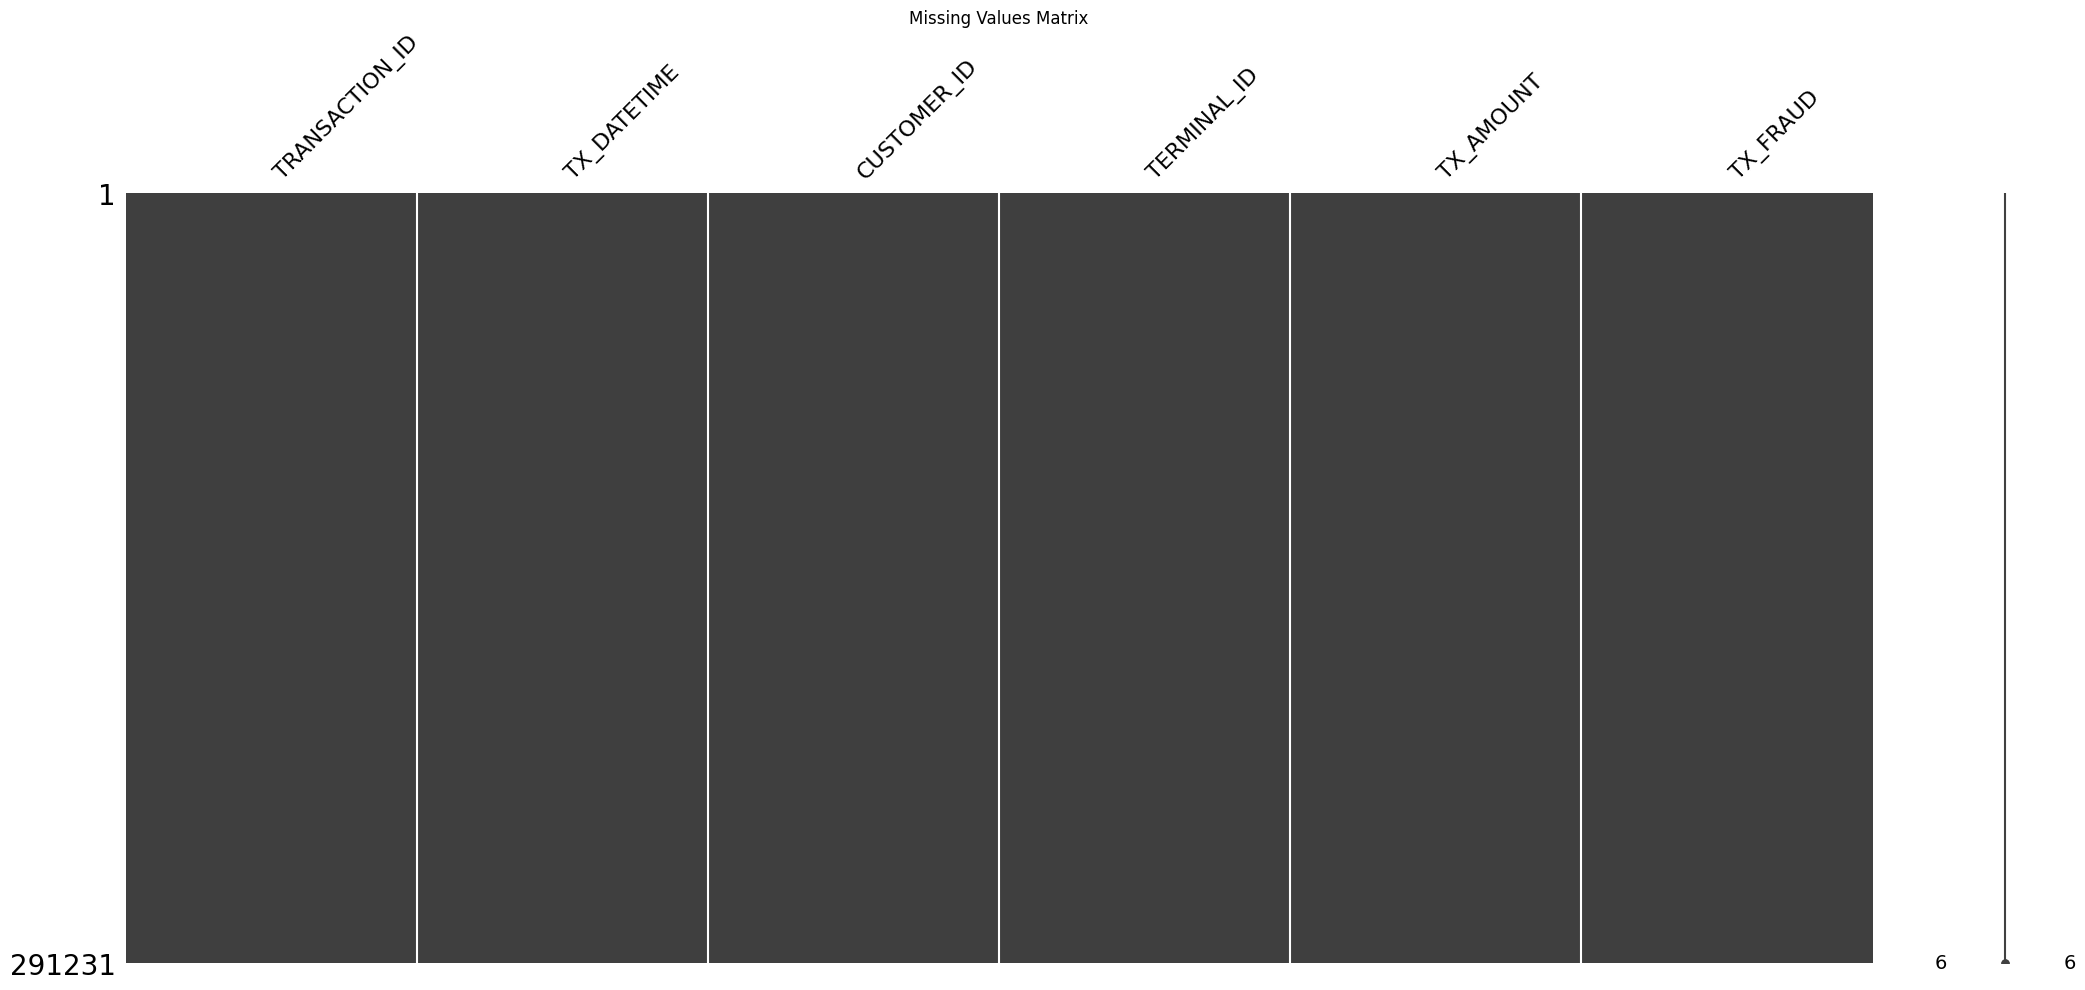

In [6]:
msno.matrix(transactions)
plt.title('Missing Values Matrix')
plt.show()

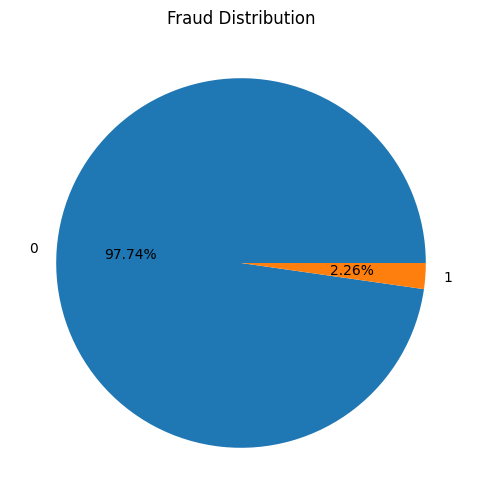

In [7]:
fraud_counts = transactions['TX_FRAUD'].value_counts()

plt.figure(figsize=(6,6))
fraud_counts.plot(kind='pie', autopct='%1.2f%%')
plt.title('Fraud Distribution')
plt.ylabel('')
plt.show()